# Unsupervised Learning: K-Means Clustering untuk Parfum

Di notebook ini, kita menggunakan algoritma **Unsupervised Learning (K-Means)** untuk membuat target (label) klaster parfum berdasarkan wangi (deskripsi) atau karakteristiknya.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import nltk
from nltk.stem import WordNetLemmatizer
import re

import warnings
warnings.filterwarnings('ignore')

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

## 2. Load Dataset & Persiapan Label (K-Means)

In [2]:
# Load dataset
df = pd.read_csv('final_perfume_data.csv', encoding='latin1')

# --- PREPROCESSING BARU ---
# Hapus baris parfum yang tidak memiliki data Notes (NaN)
df = df.dropna(subset=['Notes'])

# Mengisi nilai kosong pada Description jika ada
df['Description'] = df['Description'].fillna('')

# Membuat fitur teks gabungan untuk clustering
df['Karakteristik'] = df['Description'] + " " + df['Notes']

# Lemmatization & Pembersihan Teks
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    words = [lemmatizer.lemmatize(w) for w in text.split()]
    return " ".join(words)

df['Karakteristik_Clean'] = df['Karakteristik'].apply(preprocess_text)

# Custom Stop Words khusus domain (parfum, fragrance, scent, dll)
custom_stop_words = list(ENGLISH_STOP_WORDS.union(['fragrance', 'scent', 'notes', 'parfum', 'perfume']))

# Proses TF-IDF
tfidf_kmeans = TfidfVectorizer(stop_words=custom_stop_words, max_features=1000)
X_unsupervised = tfidf_kmeans.fit_transform(df['Karakteristik_Clean'])

### 2.1 Evaluasi Jumlah Cluster (Elbow Method & Silhouette Score)
Mencari nilai K yang paling optimal untuk dataset ini.

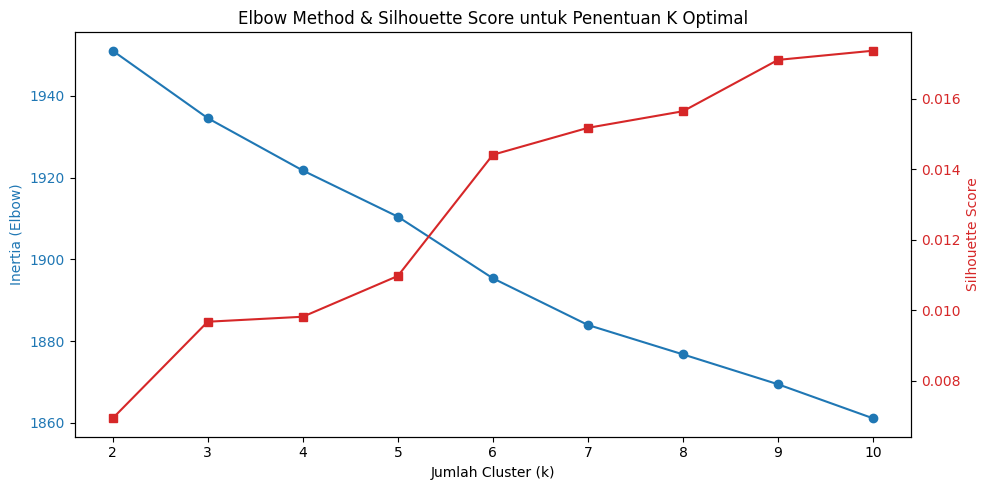

Optimal K berdasarkan Silhouette Score: 10


In [3]:
inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    # Menggunakan random_state agar hasil konsisten
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_unsupervised)
    inertia.append(kmeans_temp.inertia_)
    
    # Silhouette Score
    score = silhouette_score(X_unsupervised, kmeans_temp.labels_)
    sil_scores.append(score)

# Plotting Elbow (Inertia) dan Silhouette Score
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('Inertia (Elbow)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)  
ax2.plot(K_range, sil_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method & Silhouette Score untuk Penentuan K Optimal')
fig.tight_layout()  
plt.show()

# Mencari K dengan Silhouette Score tertinggi
optimal_k = K_range[np.argmax(sil_scores)]
print(f"Optimal K berdasarkan Silhouette Score: {optimal_k}")

### 2.2 Final Clustering & Analisis Top Keywords
Fit KMeans dengan k optimal dan lihat kata kunci teratas pada masing-masing centroid.

In [4]:
# Fit K-Means Final
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_Aroma'] = kmeans_final.fit_predict(X_unsupervised)

# Menampilkan top keywords untuk penamaan klaster
print("Top terms per cluster:")
order_centroids = kmeans_final.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_kmeans.get_feature_names_out()

for i in range(optimal_k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_terms)}")

print("\nTabel dengan label Cluster (Unsupervised Pseudo-label):")
display(df[['Name', 'Description', 'Notes', 'Cluster_Aroma']].head())

Top terms per cluster:
Cluster 0: rose, musk, patchouli, amber, pink, note, absolute, black, turkish, pepper
Cluster 1: green, lemon, citrus, vetiver, fresh, note, lavender, bergamot, tea, mint
Cluster 2: incense, wood, vetiver, pepper, black, note, like, cedar, sandalwood, patchouli
Cluster 3: orange, blossom, neroli, musk, jasmine, flower, note, fresh, citrus, mandarin
Cluster 4: vanilla, patchouli, amber, tobacco, sweet, rich, gourmand, chocolate, dark, warm
Cluster 5: ingredient, list, ford, tom, time, private, receive, vary, refer, click
Cluster 6: leather, saffron, note, violet, amber, smoky, accord, patchouli, black, tobacco
Cluster 7: ylang, vanilla, jasmine, tuberose, flower, sandalwood, rose, musk, like, floral
Cluster 8: oud, rose, note, oil, saffron, agarwood, patchouli, amber, wood, rich
Cluster 9: white, musk, flower, jasmine, iris, floral, sandalwood, tuberose, note, lily

Tabel dengan label Cluster (Unsupervised Pseudo-label):


,Name,Description,Notes,Cluster_Aroma
0,Tihota Eau de Parfum,"Rapa Nui for sugar, Tihota is, quite simply, ...","Vanilla bean, musks",4
1,Sola Parfum,A tribute to the expanse of space extending f...,"Lavender, Yuzu, Lemongrass, Magnolia, Geraniu...",1
2,Kagiroi Parfum,An aromatic ode to the ancient beauty of Japa...,"Green yuzu, green shikuwasa, sansho seed, cor...",1
3,Velvet Fantasy Eau de Parfum,Velvet Fantasy is a solar fragrance where cit...,"tangerine, pink pepper, black coffee, leat...",4
4,A Blvd. Called Sunset Eau de Parfum,There's no way A Lab On Fire could relocate t...,"Bergamot, almond, violet, jasmine, leather, s...",6


### 2.3 Visualisasi (PCA)
Mereduksi dimensi teks dengan PCA atau t-SNE untuk memvisualisasikan persebaran klaster secara 2D.

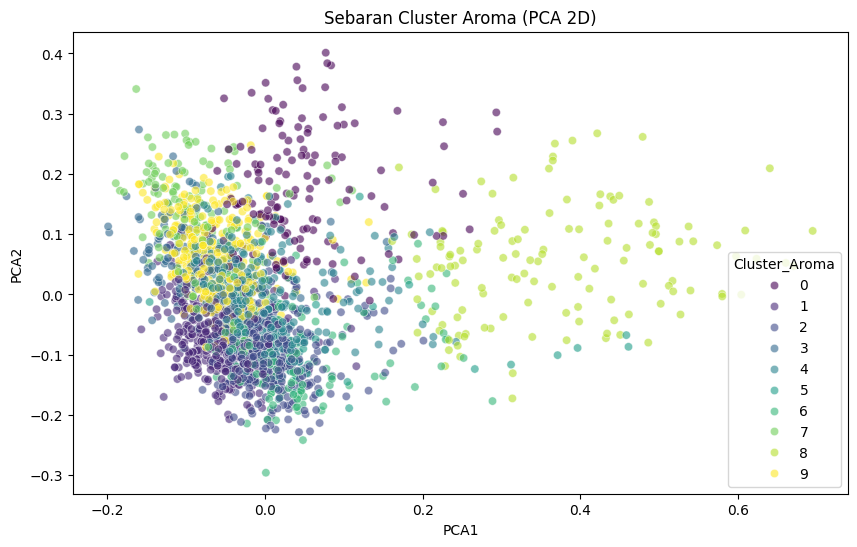

In [5]:
# PCA Reduksi Dimensi ke 2D
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X_unsupervised.toarray())

df['PCA1'] = pca_features[:, 0]
df['PCA2'] = pca_features[:, 1]

# Scatter Plot PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster_Aroma',
    palette='viridis',
    data=df,
    legend='full',
    alpha=0.6
)
# Note: Centroid di PCA space juga bisa di plot jika diperlukan, namun untuk kemudahan visualisasi pada 2D Cukup dengan persebaran datanya.
plt.title('Sebaran Cluster Aroma (PCA 2D)')
plt.show()

## 3. Simpan Hasil Clustering

In [6]:
df.to_csv('final_perfume_data_with_clusters.csv', index=False)
print("Data berhasil disimpan ke final_perfume_data_with_clusters.csv")

Data berhasil disimpan ke final_perfume_data_with_clusters.csv
